# Partie B: Regression

- **Dataset**: California Housing
- **Objectif**: prédire le prix médian des maisons (variable continue).

In [75]:
# Importation des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ridge et Lasso Lib
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# 1. Chargement:

Partir du notebook `Regression - California Housing.ipynb`


In [76]:
# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

# print("Path to dataset files:", path) # Afficher le lien vers le Dataset

df = pd.read_csv(path + "/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [77]:
ds = sklearn.datasets.fetch_california_housing()
df = pd.DataFrame(ds.data, columns=ds.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


# 2. Nettoyage et prétraitement:

In [78]:
# Nettoyage er Prétraitement
## Remplir NaN par la Moyenne
df=df.fillna(df.mean())

## DataFrame Du target : MedHouseVal
df_target= pd.DataFrame(ds.target,columns=ds.target_names)
df_target.head() # Affichage des Targets

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


# 3. EDA :

In [79]:
# Statistique Descriptive
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


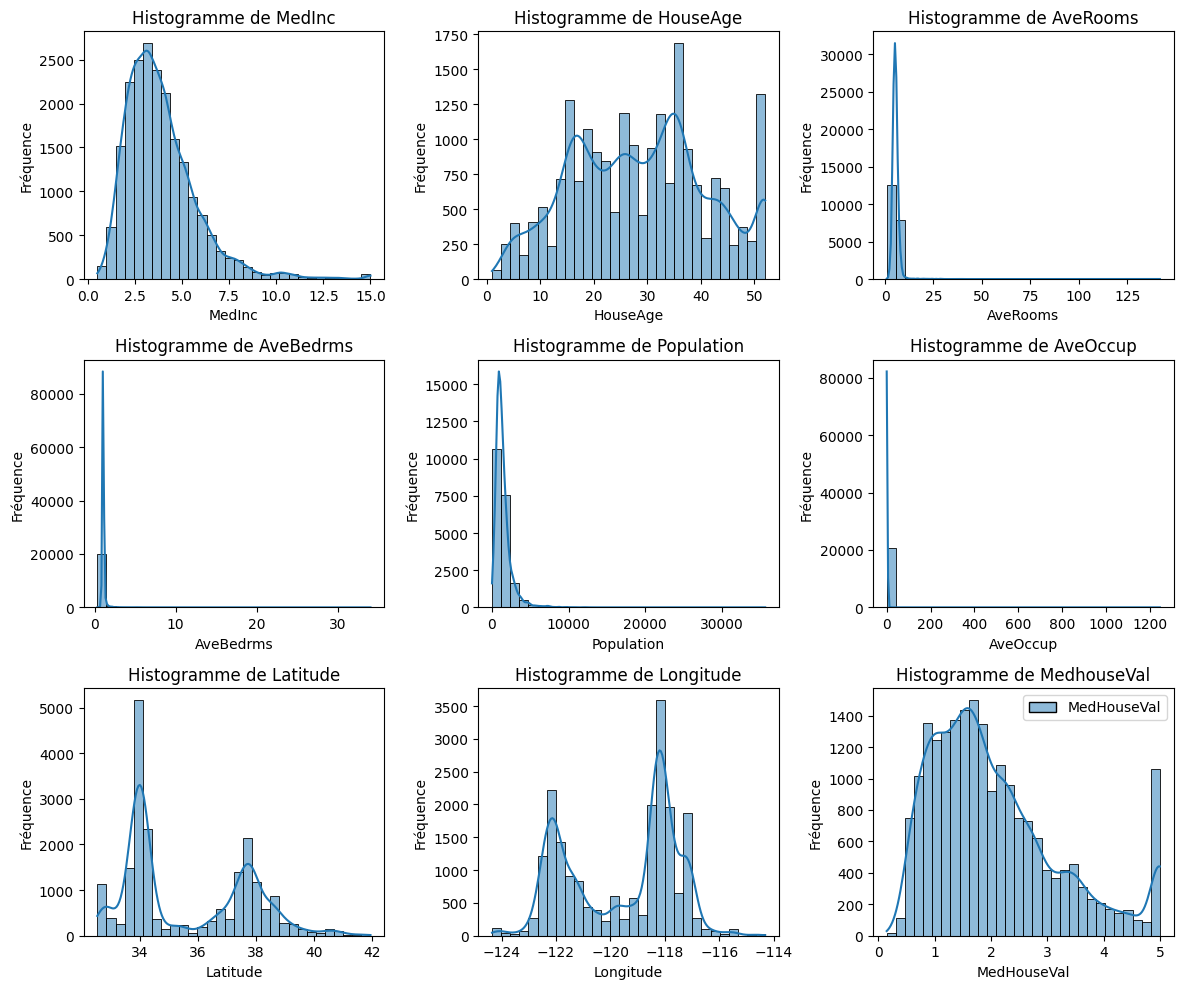

In [80]:
# Histogramme de Chaque Variables
#df.hist(figsize=(10, 8), bins=20)
#plt.tight_layout()
#plt.show()
plt.figure(figsize=(12, 10))
for i,column in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f"Histogramme de {column}")
    plt.xlabel(column)
    plt.ylabel("Fréquence")

plt.subplot(3,3,9)
sns.histplot(df_target, kde=True, bins=30)
plt.title(f"Histogramme de {"MedhouseVal"}")
plt.xlabel("MedHouseVal")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()



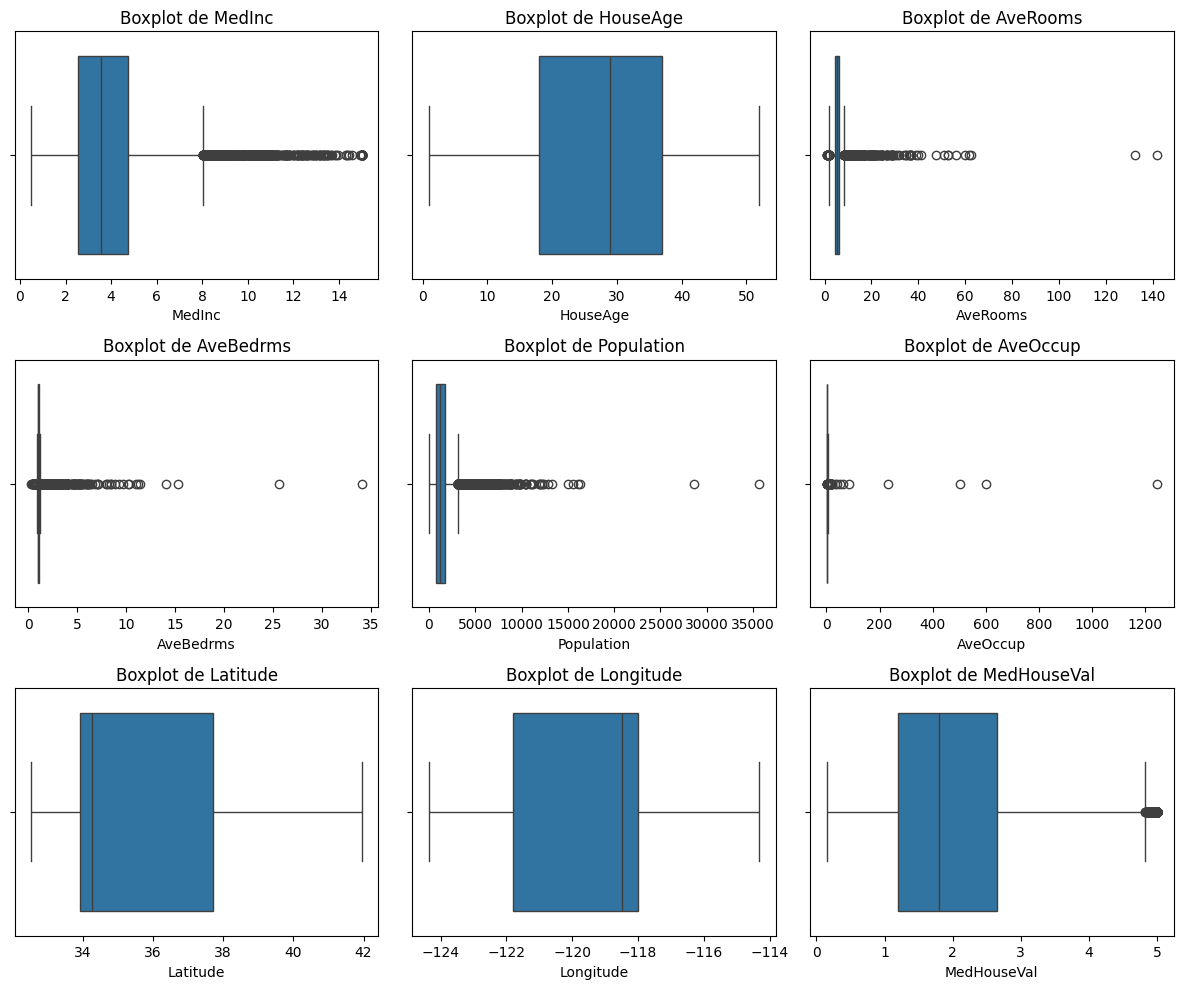

In [81]:
# Boxplot de Chaque Variables
#df.boxplot(figsize=(10, 8))
#plt.tight_layout()
#plt.show()

plt.figure(figsize=(12, 10))
for i,column in enumerate(df.select_dtypes(include='number').columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot de {column}")
    plt.xlabel(column)

plt.subplot(3,3,9)
sns.boxplot(x=df_target["MedHouseVal"])
plt.title(f"Boxplot de {"MedHouseVal"}")
plt.xlabel("MedHouseVal")

plt.tight_layout()
plt.show()


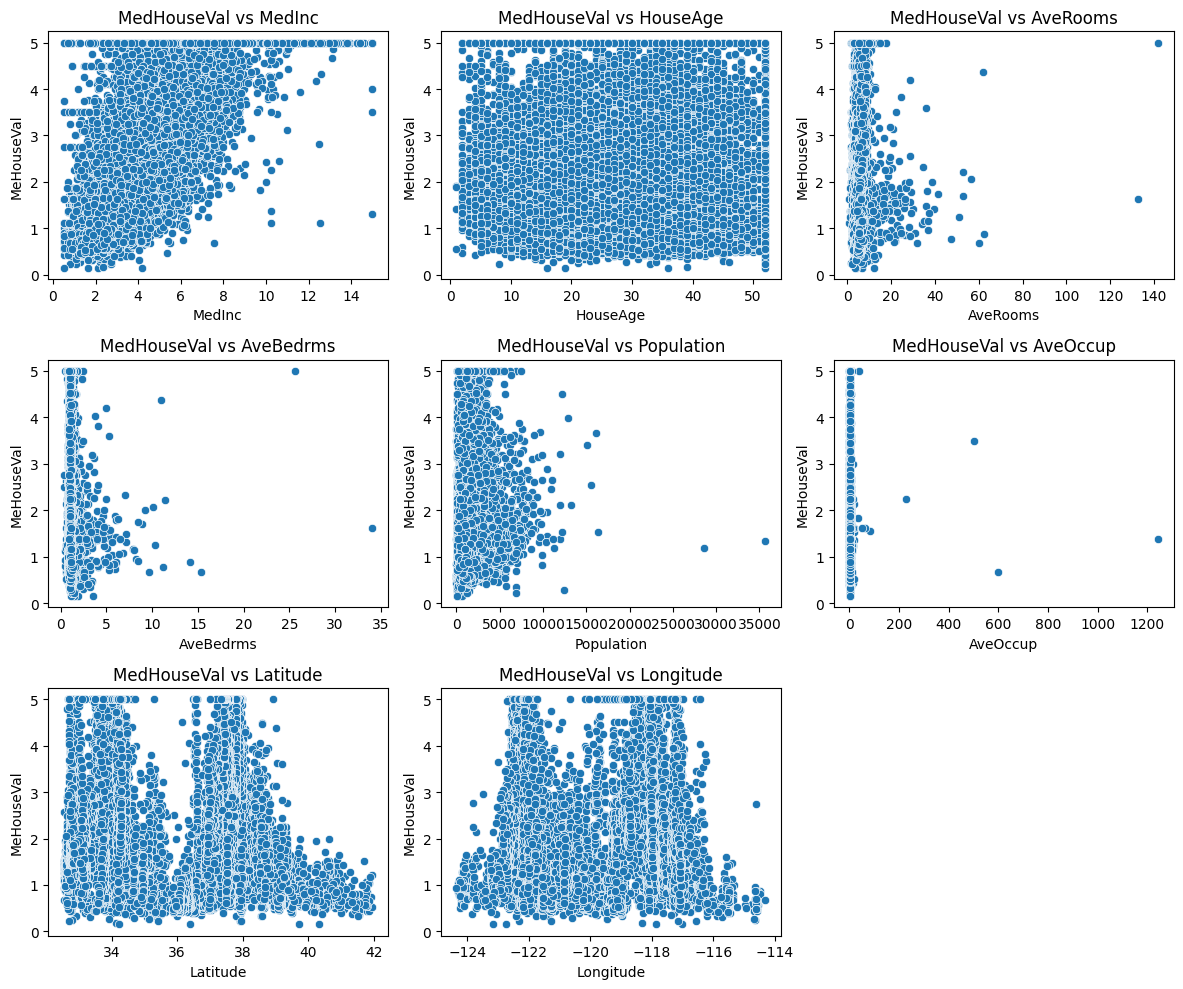

In [82]:
# Scatter Plot Prix vs Variables Clés
#sns.pairplot(df, kind='scatter')
#plt.show()
plt.figure(figsize=(12, 10))
for i,col in enumerate(df.select_dtypes(include='number').columns):
    plt.subplot(3,3,i+1)
    sns.scatterplot(x=df[col], y=df_target['MedHouseVal'])
    plt.title(f"{"MedHouseVal"} vs {col}")
    plt.xlabel(col)
    plt.ylabel("MeHouseVal")

plt.tight_layout()
plt.show()


La matrice de Correlation :               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   

            Latitude  Longitude  
MedInc     -0.079809  -0.015176  
HouseAge    0.011173  -0.108197  
AveRooms    0.106389  -0.027540  
AveBedrms   0.069721   0.013344  
Population -0.108785   0.099773  
AveOccup    0.002366   0.002476  
Latitude    1.000000  -0.924664  
Longit

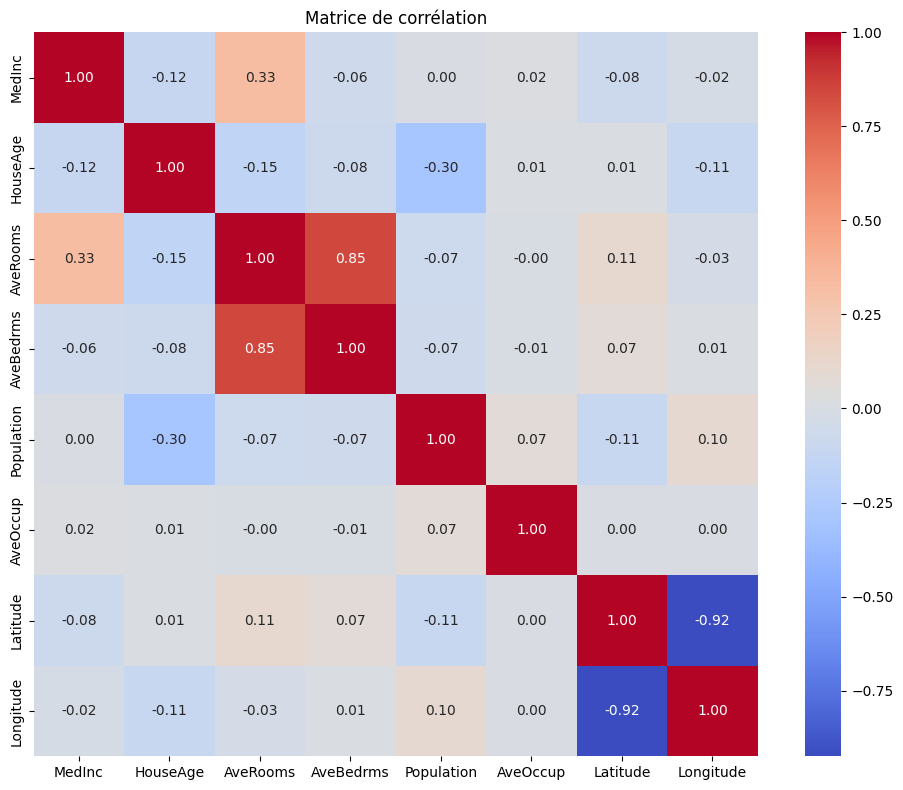

In [83]:
# Matrice de Correlation 
corr_matrix=df.corr()
print("La matrice de Correlation :",corr_matrix)

# Affichage en HeatMap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()


# 4. Split train/validation/test:

In [84]:
# Creation des Varibles X et Y
X=df

## Y => MedHouseVal
Y=df_target


In [85]:
# Spilter en 60% train , 20% validation , 20% test
X_train, X_valtest, y_train, y_valtest = train_test_split(X,Y, test_size=0.4, random_state=0)

X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=0)

# 5. Feature engineering / sélection:

In [86]:
# Standardisation avec StandarScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.fit_transform(X_val)
X_test_scaled  = scaler.fit_transform(X_test)

# Reconversion en Dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X.columns)
X_val_scaled_df   = pd.DataFrame(X_val_scaled,columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,columns=X.columns)

# Test d'affichage
X_train_scaled_df.head()
X_val_scaled_df.head()
X_test_scaled_df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.181125,0.572075,-0.453179,-0.122431,-0.087110,1.827926,-0.626800,0.544247
1,-0.375272,0.651355,-0.431234,-0.205749,0.123985,0.640590,-0.692440,0.815172
2,-0.192619,-1.409934,-0.416756,-0.173202,0.611972,0.138806,-1.419162,1.236610
3,-0.885904,-0.617131,-0.550900,-0.116303,-0.406038,-0.332025,0.643792,-1.251882
4,-0.933276,1.127037,-0.480899,-0.080570,0.208972,1.823256,-0.767456,0.644590


# 6. Baseline et Modelisation Initiale

In [87]:
# Regression Lineaire
model = LinearRegression()
model.fit(X_train_scaled, y_train) # Entrainement

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
# Predictions sur les set de Validation
y_val_prediction=model.predict(X_val_scaled)

In [89]:
# Rapport de MSE , MAE ,R2
mse = mean_squared_error(y_val, y_val_prediction)
mae = mean_absolute_error(y_val, y_val_prediction)
r2 = r2_score(y_val, y_val_prediction)

# Affiachage des Valeurs
print(f"MSE (validation) : {mse:.8f}")
print(f"MAE (validation) : {mae:.8f}")
print(f"R² (validation)  : {r2:.8f}")

MSE (validation) : 0.53401641
MAE (validation) : 0.53129286
R² (validation)  : 0.59374202


# 7. Regularisation :

## 7.1 Ridge : Pour la multicolinéarité

In [90]:
# Ridge pour la multicoliéarité
# Ridge Regression
ridge_model = Ridge(alpha=1.0) 
ridge_model.fit(X_train_scaled, y_train) # Entrainement


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [91]:
# Prediction sur le Set de validation
y_val_pred_ridge=ridge_model.predict(X_val_scaled)

In [92]:
# Rapport de MSE , MAE , R2
mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
r2_ridge = r2_score(y_val, y_val_pred_ridge)

# Affichage des Valeurs
print(f"MSE (validation) : {mse_ridge:.8f}")
print(f"MAE (validation) : {mae_ridge:.8f}")
print(f"R² (validation)  : {r2_ridge:.8f}")

MSE (validation) : 0.53402619
MAE (validation) : 0.53129143
R² (validation)  : 0.59373458


# 7.2 Lasso : Pour selectionner les features

In [93]:
# Lasso pour selectionner les Features
# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train) # Entrainement

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [94]:
# Prediction sur le Set de Validation
y_val_pred_lasso = lasso_model.predict(X_val_scaled)

In [95]:
# Rapport de MSE, MAE, R2
mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
r2_lasso = r2_score(y_val, y_val_pred_lasso)

# Affichage des Valeurs
print(f"MSE (validation) : {mse_ridge:.8f}")
print(f"MAE (validation) : {mae_ridge:.8f}")
print(f"R² (validation)  : {r2_ridge:.8f}")

MSE (validation) : 0.53402619
MAE (validation) : 0.53129143
R² (validation)  : 0.59373458


# 8. Evaluation finale:

In [96]:
# Evaluation finale

## Varible pour stocker les Resulat de Chaque Model 
resultat={
    "Methode":["Linear","Ridge","Lassso"],
    "MSE":[mse,mse_ridge,mse_lasso],
    "MAE":[mae,mae_ridge,mae_lasso],
    "R2":[r2,r2_ridge,r2_lasso],
}
result_df=pd.DataFrame(resultat)

min_mse=result_df["MSE"].min()
index_min_mse=result_df.index[result_df["MSE"] == min_mse].tolist()

min_mae=result_df["MAE"].min()
index_min_mae=result_df.index[result_df["MAE"] == min_mae].tolist()

max_r2=result_df["R2"].max()
index_max_r2= result_df.index[result_df["R2"] == max_r2].tolist()

print("Minimum MSE:",min_mse,"indice:",index_min_mse)
print("Minimum MAE:",min_mae,"indice:",index_min_mae)
print("Maximum R2:",max_r2, "indice:",index_max_r2)

result_df.head()

Minimum MSE: 0.5340164142755626 indice: [0]
Minimum MAE: 0.5312914251865469 indice: [1]
Maximum R2: 0.5937420184471691 indice: [0]


,Methode,MSE,MAE,R2
0,Linear,0.534016,0.531293,0.593742
1,Ridge,0.534026,0.531291,0.593735
2,Lassso,0.684672,0.621101,0.479129


In [97]:
# Linear Regression offre le meilleur model

# Application du set test sur Linear Regression
y_test_pred = model.predict(X_test_scaled)

In [98]:
# Rapport des MSE ,MAE et R2
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"MSE (test) : {mse_test:.8f}")
print(f"MAE (test) : {mae_test:.8f}")
print(f"R² (test)  : {r2_test:.8f}")


MSE (test) : 0.52784174
MAE (test) : 0.53000722
R² (test)  : 0.60954143


In [99]:
# Intervalles de Confiance
# TODO:


# 9. Conclusion: